In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import optuna
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## Dane treningowe

In [74]:
df_ex = pd.read_csv('../data/df_ex.csv')
df_ex = df_ex.drop(['Unnamed: 0'], axis=1)

In [75]:
df_ex.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back', 'loan_to_income', 'subgrade_num',
       'grade_letter_rank', 'education_rank', 'gender_Male', 'gender_Other',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Retired',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'disposable_income',
       'interest_to_income_ratio', 'risk_score_ratio', 'dti_squared',
       'loan_per_credit_point'],
      dtype='object')

In [76]:
X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

In [77]:
expected_features = X.columns
joblib.dump(expected_features, '../models/features.pkl')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Dane testowe

In [78]:
def prepare_submission_data2(df):
    df_ex = df.copy()
    df_ex['grade_letter'] = df['grade_subgrade'].str[0]
    df_ex['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)

    grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
    df_ex['grade_letter_rank'] = df_ex['grade_letter'].map(grade_map)
    
    del df_ex['grade_subgrade']
    del df_ex['grade_letter']

    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df_ex['education_rank'] = df_ex['education_level'].map(education_ranking)

    del df_ex['education_level']

    df_ex = pd.get_dummies(df_ex, columns=['gender', 'marital_status', 'employment_status', 'loan_purpose'], drop_first=True)

    return df_ex

In [79]:
def apply_feature_engineering(df):

    df['loan_to_income'] = df['loan_amount'] / df['annual_income']
    df['disposable_income'] = df['annual_income'] * (1 - df['debt_to_income_ratio'])
    df['interest_to_income_ratio'] = (df['loan_amount'] * df['interest_rate']) / df['annual_income']
    df['risk_score_ratio'] = df['interest_rate'] / (df['credit_score'] + 1)
    df['dti_squared'] = df['debt_to_income_ratio'] ** 2
    df['loan_per_credit_point'] = df['loan_amount'] / df['credit_score']
    
    return df

In [80]:
test = pd.read_csv('../data/test.csv')
expected_features =  joblib.load('../models/features.pkl')
test_ids = test['id']

X_test = prepare_submission_data2(test)
X_test = apply_feature_engineering(X_test)
X_test = X_test.reindex(columns=expected_features, fill_value=0)

In [81]:
m_xgb = xgb.Booster()
m_xgb.load_model("../models/loan_repayment_model_26.03_XGBoost.json")
print('xgb')
m_lgbm = lgb.Booster(model_file="../models/loan_repayment_model_26.03_Lightgbm.json")
print('lgb')
m_cat = CatBoostClassifier()
m_cat.load_model("../models/loan_repayment_model_26.03_CatBoost.json")
print('cat')
logit = joblib.load('../models/logit_model.pkl')
print('logit')
rf = joblib.load('../models/rf_model.pkl')
print('rf')

xgb
lgb
cat
logit
rf


In [82]:
xgb_pred = m_xgb.predict(xgb.DMatrix(X_test))
lgbm_pred = m_lgbm.predict(X_test)
cat_pred = m_cat.predict_proba(X_test)[:,1]
rf_pred = rf.predict_proba(X_test)[:,1]
logit_pred = logit.predict_proba(X_test.values)[:,1]

C:\Users\VMUser\miniconda3\envs\ml_clean\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [83]:
df_preds = pd.DataFrame({
    "xgb": xgb_pred,
    "lgbm": lgbm_pred,
    "cat": cat_pred,
    "rf": rf_pred, 
    "logit": logit_pred
})

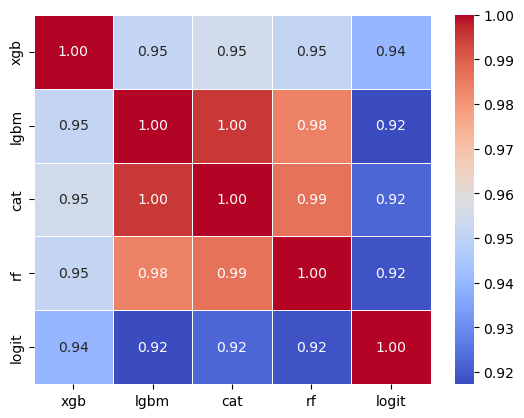

In [85]:
corr = df_preds.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.show()

# bardzo wysoka korelacja CatBoost i LightGBM, a także z RandomForest
# niższa korelacja regresji logistycznej i XGBoost z pozostałymi modelami

## Modele pojedyncze

In [86]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 63,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbosity': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    models.append(model)

full_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {full_auc:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.916915	valid's auc: 0.917272
[200]	train's auc: 0.921142	valid's auc: 0.919369
[300]	train's auc: 0.924767	valid's auc: 0.92082
[400]	train's auc: 0.927265	valid's auc: 0.921331
[500]	train's auc: 0.93001	valid's auc: 0.922062
[600]	train's auc: 0.932439	valid's auc: 0.922593
[700]	train's auc: 0.934231	valid's auc: 0.922779
[800]	train's auc: 0.936059	valid's auc: 0.922916
Early stopping, best iteration is:
[822]	train's auc: 0.936364	valid's auc: 0.92294
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.917098	valid's auc: 0.91648
[200]	train's auc: 0.92081	valid's auc: 0.918271
[300]	train's auc: 0.92454	valid's auc: 0.920066
[400]	train's auc: 0.927561	valid's auc: 0.921225
[500]	train's auc: 0.929937	valid's auc: 0.921798
[600]	train's auc: 0.932042	valid's auc: 0.922166
[700]	train's auc: 0.93397	valid's auc: 0.922284
Early stopping, best iteration is:
[693]	train's a

In [ ]:
model.save_model('../models/loan_repayment_model_26.03_Lightgbm.json')

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.014366,
    'max_depth': 10,
    'min_child_weight': 10,
    'subsample': 0.8629,
    'colsample_bytree': 0.5000,
    'gamma': 0.0011,
    'lambda': 1.45e-08,
    'alpha': 1.36e-08,
    'random_state': 42
}
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    oof_preds[val_idx] = model.predict(dval)
    models.append(model)

In [ ]:
model.save_model('..//models/loan_repayment_model_26.03_XGBoost.json')

In [ ]:
# 1. Obliczamy ogólne AUC
auc_total = roc_auc_score(y, oof_preds)
print(f"Final OOF AUC: {auc_total:.4f}")

# 2. Zamieniamy prawdopodobieństwa na klasy (próg 0.5)
# Możesz eksperymentować z tym progiem!
oof_classes = (oof_preds > 0.5).astype(int)

print("\nRaport klasyfikacji:")
print(classification_report(y, oof_classes))

In [ ]:
def objective(trial, X, y):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_train, label=y_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
        )

        preds = model.predict(X_val)
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

# --- Uruchomienie badania ---
study = optuna.create_study(direction='maximize')
# Przekazujemy X i y za pomocą lambda, aby funkcja objective mogła je przyjąć
study.optimize(lambda trial: objective(trial, X, y), n_trials=50)

print("Najlepszy wynik AUC:", study.best_value)
print("Najlepsze parametry:", study.best_params)

In [ ]:
cat_features = list(X.select_dtypes(include=['category', 'object']).columns)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        verbose=100,     
        early_stopping_rounds=50,
        use_best_model=True   
    )
    
    model.fit(train_pool, eval_set=val_pool)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)

print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.4f}")

In [ ]:
model.save_model('..//models/loan_repayment_model_26.03_CatBoost.json')

In [34]:
# Wybraliśmy regresję logistyczną, bo dobrze pasuje do problemu przewidywania spłaty (0/1), jest prosta, stabilna i 
# łatwa do interpretacji, oraz stanowi solidny benchmark w zadaniach scoringowych.
# Zastosowana standaryzacja oraz class_weight='balanced', żeby lepiej radzić sobie z niezbalansowanymi danymi
# Ponadto staralismy się maksymalizować recall dla 0, zachowując balans z pozostałymi metrykami, ponieważ z perspektywy kredytodawcy
# kluczowe jest wychwycenie jak największej liczby potencjalnych niespłacających, nawet kosztem większej liczby fałszywych alarmów

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=100,
        class_weight='balanced',
        random_state=42
    ))
])

kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=kfold,
    scoring='roc_auc'
)

pipe.fit(X_train, y_train)  
y_pred_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred_class))

print("AUC dla foldów:", scores)
print("Średni AUC:", scores.mean())

              precision    recall  f1-score   support

         0.0       0.62      0.78      0.69     23900
         1.0       0.94      0.88      0.91     94899

    accuracy                           0.86    118799
   macro avg       0.78      0.83      0.80    118799
weighted avg       0.87      0.86      0.86    118799

AUC dla foldów: [0.91175449 0.9095526  0.90965643 0.91085767]
Średni AUC: 0.9104552970193894


In [ ]:
joblib.dump(pipe, '../models/logit_model.pkl')

In [ ]:
# poszukiowanie najlepszych parametrów dla RandomForest
best_auc = 0
best_params = {}

for n in [200, 300, 400, 500, 600]:
    for weight in [{0:3,1:1}, {0:4,1:1}, {0:5,1:1}, {0:6,1:1}]:
        model = RandomForestClassifier(n_estimators=n, class_weight=weight, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        y_val_pred = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_val_pred)
        if auc > best_auc:
            best_auc = auc
            best_params = {'n_estimators': n, 'class_weight': weight}
        print('n_estimators', n, 'class_weight', weight)

print("Najlepsze parametry:", best_params)
print("Najlepsze AUC:", best_auc)

In [ ]:
# Random Forest został wykorzystany jako bardziej elastyczny model, zdolny uchwycić nieliniowe zależności i interakcje 
# między zmiennymi, których regresja logistyczna może nie wychwycić. 
# Odporny na overfitting i dobrze radzi sobie z danymi tabularnymi bez silnych założeń co do ich rozkładu.

pipe = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=n,
        max_depth=None,
        class_weight=weight,
        random_state=42,
        n_jobs=-1
    ))
])

kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=kfold,
    scoring='roc_auc'
)

pipe.fit(X_train, y_train)  

y_pred_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_prob > 0.6).astype(int)

print(classification_report(y_test, y_pred_class))
print("AUC dla foldów:", scores)
print("Średni AUC:", scores.mean())

In [ ]:
joblib.dump(pipe, '../models/rf_model.pkl')

## Modelowanie z głosowaniem

In [35]:
# soft voting w celu poprawy  predykcyjności
voting_pred_proba = (0.41223535 * xgb_pred) + (0.53058813 * lgbm_pred) + (0 * cat_pred) + (0.05717652 * rf_pred)  + (0 * logit_pred)
# voting_pred_proba = (0 * xgb_pred) + (1 * lgbm_pred) + (0 * cat_pred) + (0 * rf_pred)  + (0 * logit_pred)

In [36]:
voting_pred_proba

array([0.89127716, 0.93247291, 0.50291469, ..., 0.92751974, 0.94393263,
       0.89248194], shape=(254569,))

In [ ]:
submission = pd.DataFrame({'id': test_ids, 'loan_paid_back': voting_pred_proba})
submission.to_csv('../submissions/28.03_2_voting_submission.csv', index=False)